In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mdimranulhuq/deforestation-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 3.03G/3.03G [00:34<00:00, 93.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mdimranulhuq/deforestation-image-dataset/versions/1


In [ ]:
import os
new_path = "/content"

import shutil
shutil.move(path, new_path)

'/content/1'

In [ ]:
import os
import numpy as np
import cv2
from glob import glob
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.model_selection import train_test_split

def load_data(dataset_path, target_size=(224, 224)):
    images, masks = [], []

    for year in sorted(os.listdir(dataset_path)):  # Iterate over years
        year_path = os.path.join(dataset_path, year)
        if os.path.isdir(year_path):
            raw_images_path = os.path.join(year_path, "Raw")
            annotated_mask_path = os.path.join(year_path, "Annotated & Mask")

            if os.path.exists(raw_images_path) and os.path.exists(annotated_mask_path):
                for image_path in glob(os.path.join(raw_images_path, "*.*")):
                    filename = os.path.basename(image_path)  # e.g., "2010Airport(1).jpg"
                    base_name, _ = os.path.splitext(filename)  # Remove extension

                    # Find the correct mask (must contain "_mask")
                    mask_candidates = glob(os.path.join(annotated_mask_path, f"{base_name}_mask.*"))

                    if mask_candidates:
                        mask_path = mask_candidates[0]  # Use the first valid mask

                        # Load and preprocess raw image
                        img = cv2.imread(image_path)
                        img = cv2.resize(img, target_size)
                        img = img_to_array(img) / 255.0

                        # Load and preprocess mask
                        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                        mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
                        mask = (mask > 0).astype(np.float32)  # Binarize mask
                        mask = np.expand_dims(mask, axis=-1)  # Add channel dimension

                        images.append(img)
                        masks.append(mask)

    return np.array(images), np.array(masks)

# Load Data
dataset_path = "/content/1"
images, masks = load_data(dataset_path)

print(f"Loaded {len(images)} images and {len(masks)} masks.")

Loaded 1253 images and 1253 masks.


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)
print(f"Training: {X_train.shape}, Validation: {X_val.shape}")

Training: (1002, 224, 224, 3), Validation: (251, 224, 224, 3)


In [ ]:
from tensorflow.keras.layers import Activation, Add


In [ ]:
from tensorflow.keras.layers import Multiply, Conv2D, Add
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate
from tensorflow.keras.models import Model

def attention_gate(x, g, filters):
    """
    Attention Gate to focus on relevant features in the decoder.
    :param x: Feature map from the encoder.
    :param g: Skip connection from the encoder.
    :param filters: Number of filters for the convolution layers.
    :return: Attention-modulated feature map.
    """
    theta_x = Conv2D(filters, (1, 1), padding='same')(x)
    phi_g = Conv2D(filters, (1, 1), padding='same')(g)

    # Add and apply ReLU activation
    add = Add()([theta_x, phi_g])
    add = Activation('relu')(add)

    # Output attention map
    psi = Conv2D(1, (1, 1), padding='same', activation='sigmoid')(add)
    attention = Multiply()([x, psi])

    return attention

In [ ]:
def unet_attention_model(input_size=(224, 224, 3)):
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)

    # Decoder with Attention Gates
    u5 = UpSampling2D((2, 2))(c4)
    att5 = attention_gate(c3, u5, 256)  # Apply attention gate
    m5 = Concatenate()([u5, att5])
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(m5)
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    u6 = UpSampling2D((2, 2))(c5)
    att6 = attention_gate(c2, u6, 128)  # Apply attention gate
    m6 = Concatenate()([u6, att6])
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(m6)
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(c6)

    u7 = UpSampling2D((2, 2))(c6)
    att7 = attention_gate(c1, u7, 64)  # Apply attention gate
    m7 = Concatenate()([u7, att7])
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(m7)
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c7)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# Initialize Model
model = unet_attention_model()

# Train Model
model.fit(X_train, y_train, batch_size=16, epochs=50, validation_data=(X_val, y_val))

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.7197 - loss: 0.6872 - val_accuracy: 0.7723 - val_loss: 0.4242
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 76s 616ms/step - accuracy: 0.7726 - loss: 0.4429 - val_accuracy: 0.8155 - val_loss: 0.4044
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 649ms/step - accuracy: 0.8066 - loss: 0.4141 - val_accuracy: 0.8311 - val_loss: 0.3821
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 644ms/step - accuracy: 0.8238 - loss: 0.3886 - val_accuracy: 0.8405 - val_loss: 0.3593
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 646ms/step - accuracy: 0.8404 - loss: 0.3682 - val_accuracy: 0.8490 - val_loss: 0.3482
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 647ms/step - accuracy: 0.8514 - loss: 0.3433 - val_accuracy: 0.8442 - val_loss: 0.3612
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 647ms/step - accuracy: 0.8473 - loss: 0.3514 - val_accuracy: 0.8643 - val_loss: 0.3178
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 649ms/step - accuracy: 0.8590 - loss: 0.3295 - val_accura

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


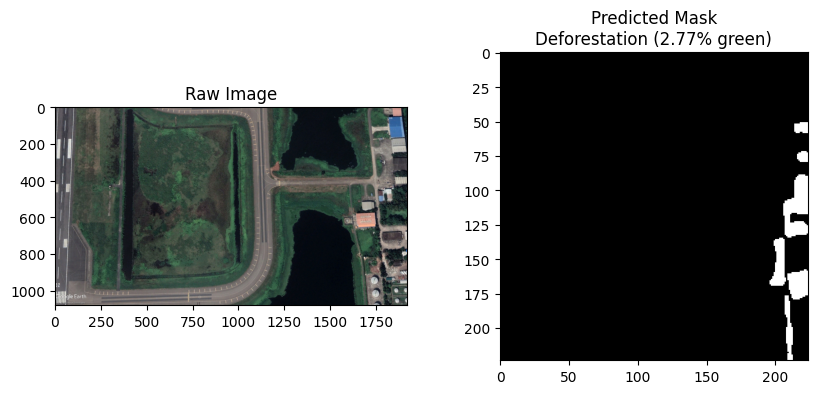

Result: Deforestation
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


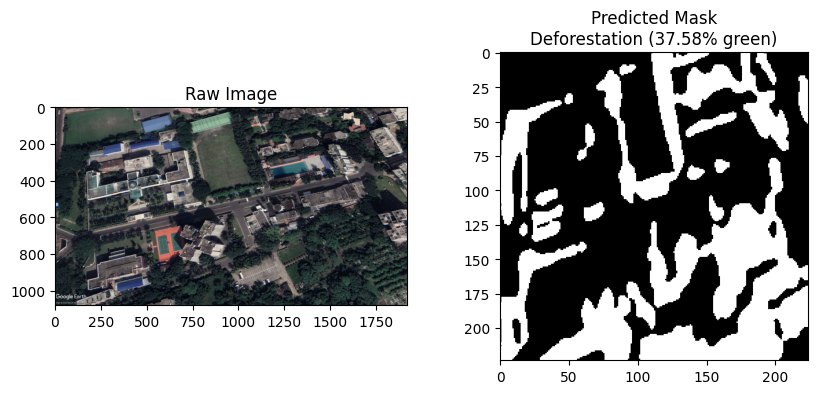

Result: Deforestation


In [ ]:
import matplotlib.pyplot as plt

def predict_and_classify(image_path, model, threshold=0.5):
    # Load Image
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict Mask
    pred_mask = model.predict(img)[0]  # Remove batch dimension
    pred_mask = (pred_mask > threshold).astype(np.uint8)  # Convert to binary

    # Calculate White Area %
    white_area = np.sum(pred_mask) / (224 * 224) * 100

    # Classify
    classification = "Non-Deforestation" if white_area > 50 else "Deforestation"

    # Display Results
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.imread(image_path)[:, :, ::-1])
    plt.title("Raw Image")

    plt.subplot(1, 2, 2)
    plt.imshow(pred_mask.squeeze(), cmap="gray")
    plt.title(f"Predicted Mask\n{classification} ({white_area:.2f}% green)")

    plt.show()

    return classification

# Example Prediction
image_path = "/content/1/2017/Raw/2017Airport(2).jpg"
result = predict_and_classify(image_path, model)
print("Result:", result)

# Example Prediction
image_path1 = "/content/1/2017/Raw/2017Banani(1).jpg"
result1 = predict_and_classify(image_path1, model)
print("Result:", result1)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, jaccard_score, f1_score

def evaluate_model(model, X_val, y_val, threshold=0.5):
    y_pred = model.predict(X_val)  # Get predictions
    y_pred = (y_pred > threshold).astype(np.uint8)  # Convert to binary mask

    iou_scores = []
    dice_scores = []
    pixel_accuracies = []

    for i in range(len(y_val)):
        true_mask = y_val[i].squeeze()  # Remove extra dimensions
        pred_mask = y_pred[i].squeeze()

        # Compute IoU
        iou = jaccard_score(true_mask.flatten(), pred_mask.flatten(), average='binary')
        iou_scores.append(iou)

        # Compute Dice Coefficient
        dice = f1_score(true_mask.flatten(), pred_mask.flatten(), average='binary')
        dice_scores.append(dice)

        # Compute Pixel Accuracy
        pixel_acc = accuracy_score(true_mask.flatten(), pred_mask.flatten())
        pixel_accuracies.append(pixel_acc)

    # Print Mean Metrics
    print(f"Mean IoU: {np.mean(iou_scores):.4f}")
    print(f"Mean Dice Coefficient: {np.mean(dice_scores):.4f}")
    print(f"Mean Pixel Accuracy: {np.mean(pixel_accuracies):.4f}")

    return np.mean(iou_scores), np.mean(dice_scores), np.mean(pixel_accuracies)

# Evaluate Model
iou, dice, pixel_acc = evaluate_model(model, X_val, y_val)

8/8 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step
Mean IoU: 0.6326
Mean Dice Coefficient: 0.7481
Mean Pixel Accuracy: 0.9184


In [ ]:
# prompt: save the model

model.save("deforestation_model.h5")


In [ ]:
# prompt: test the model

# Example of how to use the evaluate_model function after training
iou, dice, pixel_acc = evaluate_model(model, X_val, y_val)

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 354ms/step
Mean IoU: 0.6326
Mean Dice Coefficient: 0.7481
Mean Pixel Accuracy: 0.9184


In [ ]:
# prompt: test the model F1 score
# and precision and recall
# the model

import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

def evaluate_model_metrics(model, X_val, y_val, threshold=0.5):
    y_pred = model.predict(X_val)  # Get predictions
    y_pred = (y_pred > threshold).astype(np.uint8)  # Convert to binary mask

    f1_scores = []
    precision_scores = []
    recall_scores = []

    for i in range(len(y_val)):
        true_mask = y_val[i].squeeze().flatten()  # Remove extra dimensions and flatten
        pred_mask = y_pred[i].squeeze().flatten()

        # Compute F1 score
        f1 = f1_score(true_mask, pred_mask, average='binary')
        f1_scores.append(f1)

        # Compute Precision
        precision = precision_score(true_mask, pred_mask, average='binary')
        precision_scores.append(precision)

        # Compute Recall
        recall = recall_score(true_mask, pred_mask, average='binary')
        recall_scores.append(recall)

    # Print Mean Metrics
    print(f"Mean F1 Score: {np.mean(f1_scores):.4f}")
    print(f"Mean Precision: {np.mean(precision_scores):.4f}")
    print(f"Mean Recall: {np.mean(recall_scores):.4f}")

    return np.mean(f1_scores), np.mean(precision_scores), np.mean(recall_scores)

# Evaluate Model with F1, Precision, and Recall
mean_f1, mean_precision, mean_recall = evaluate_model_metrics(model, X_val, y_val)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 365ms/step
Mean F1 Score: 0.7481
Mean Precision: 0.7653
Mean Recall: 0.7479


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 356ms/step


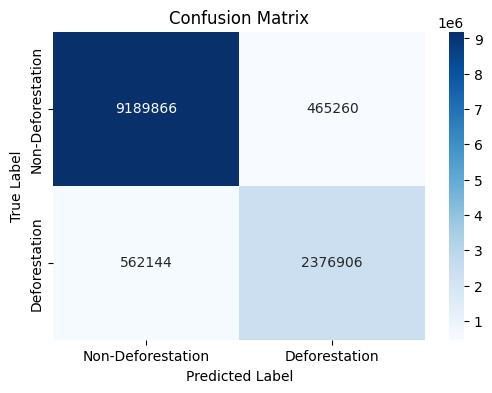

In [ ]:
# prompt: test in confusion matrix

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

def confusion_matrix_test(model, X_val, y_val, threshold=0.5):
  """
  Calculates and displays the confusion matrix for the model on the validation set.

  Args:
    model: The trained Keras model.
    X_val: The validation input data.
    y_val: The validation true labels (masks).
    threshold: The threshold for binarizing the predictions.
  """
  y_pred = model.predict(X_val)  # Get predictions
  y_pred = (y_pred > threshold).astype(np.uint8)  # Convert to binary mask

  # Flatten the true and predicted masks for confusion matrix
  y_true_flat = y_val.flatten()
  y_pred_flat = y_pred.flatten()

  # Calculate the confusion matrix
  cm = confusion_matrix(y_true_flat, y_pred_flat)

  # Display the confusion matrix using seaborn
  plt.figure(figsize=(6, 4))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Deforestation', 'Deforestation'], yticklabels=['Non-Deforestation', 'Deforestation'])
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.title('Confusion Matrix')
  plt.show()

# Test the confusion matrix
confusion_matrix_test(model, X_val, y_val)